In [4]:
import numpy as np
import pandas as pd

In [5]:
%matplotlib inline

In [6]:
import matplotlib.pyplot as plt

In [7]:
import tsfracdiff

In [8]:
from moddata import load_data

In [20]:
from arch.unitroot import ADF

## 1. Load PKO BP Stock Prices

In [9]:
data = load_data("pl_banking_stocks")

In [13]:
pkobp = data.loc[:, ("pkobp", slice(None))]
pkobp.columns = pkobp.columns.droplevel(0)

In [21]:
pkobp = pkobp[["close"]]
pkobp["lr_close"] = np.log(pkobp["close"]).diff()
pkobp["fod_close"] = pkobp["close"].diff()

In [23]:
pkobp = pkobp.loc[pkobp.isna().sum(axis=1) == 0, :]

In [24]:
pkobp.head(3)

variable,close,lr_close,fod_close
date,,,
2005-01-04,15.3820,-0.007042,-0.1087
2005-01-05,14.9438,-0.028901,-0.4382
2005-01-06,15.1664,0.014786,0.2226


## 2. Simple Differencing - Checking if Time Series is I(1)

In [25]:
fod_fig = plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

In [26]:
fod_ax = fod_fig.add_subplot(111)

In [31]:
pkobp["fod_close"].plot(ax=fod_ax)
fod_ax.grid(True)
fod_ax.set_title("First-order differences of PKO BP stock price")

Text(0.5, 1.0, 'First-order differences of PKO BP stock price')

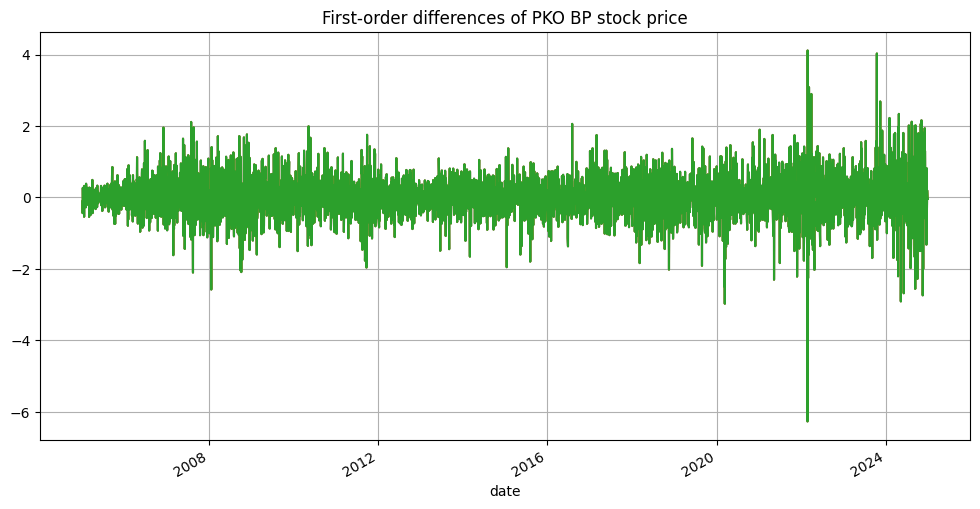

In [32]:
fod_fig

## 3. Finding Least *d* in [0,1] Making the Time Series Stationary